<a href="https://colab.research.google.com/github/Annaa74/Google-colab-models/blob/main/CNN(1)_Mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import datasets, layers , models
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical


In [ ]:
(X_train, Y_train), (X_test, Y_test) = datasets.fashion_mnist.load_data()

In [ ]:
print("Training data shape" , X_train.shape)
print("Test data shape" , X_test.shape )

Training data shape (60000, 28, 28)
Test data shape (10000, 28, 28)


In [ ]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',  'Sandal','Shirt', 'Sneaker', 'Bag', 'Ankle boot']

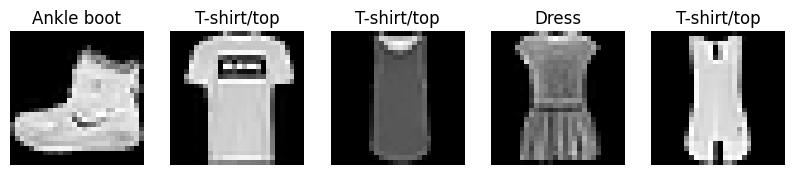

In [ ]:
plt.figure(figsize=(10,2))
for i in range(5):
  plt.subplot(1,5,i+1)
  plt.imshow(X_train[i], cmap='gray')
  plt.title(class_names[Y_train[i]])
  plt.axis('off')
plt.show()

In [ ]:
X_train = X_train / 255.0
X_test =X_test / 255.0


In [ ]:
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

In [ ]:
Y_train_cat = to_categorical(Y_train,10)
Y_test_cat = to_categorical(Y_test,10)
#

In [ ]:
X_train,X_val,Y_train_cat, y_val_cat = train_test_split(X_train,Y_train_cat,test_size=0.2,random_state=42)

In [ ]:
print("After Split:")
print("Train:", X_train.shape )
print("Validation:", X_val.shape)
print("test", X_test.shape)

After Split:
Train: (48000, 28, 28, 1)
Validation: (12000, 28, 28, 1)
test (10000, 28, 28, 1)


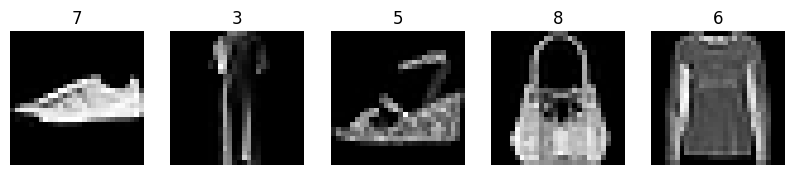

In [ ]:
plt.figure(figsize=(10,2))
for i in range(5):
  plt.subplot(1,5,i+1)
  plt.imshow(X_train[i].reshape(28,28), cmap = 'grey')
  plt.title(np.argmax(Y_train_cat[i]))
  plt.axis('off')
plt.show()

In [ ]:
model = models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10,activation='softmax')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

The formula for calculating trainable parameters in a neural network layer depends on the type of layer:

*   **Dense Layer:** `(input_units * output_units) + output_units` (the last term is for the bias)
*   **Conv2D Layer:** `(kernel_height * kernel_width * input_channels * output_channels) + output_channels` (the last term is for the bias)
*   **MaxPooling2D Layer:** `0` (no trainable parameters)

In [ ]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
history = model.fit(X_train, Y_train_cat, epochs=4,
                    validation_data=(X_val, y_val_cat))

Epoch 1/4
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 43s 29ms/step - accuracy: 0.8542 - loss: 0.4078 - val_accuracy: 0.8759 - val_loss: 0.3445
Epoch 2/4
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 80s 28ms/step - accuracy: 0.8785 - loss: 0.3379 - val_accuracy: 0.8892 - val_loss: 0.2969
Epoch 3/4
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 28ms/step - accuracy: 0.8932 - loss: 0.2938 - val_accuracy: 0.8979 - val_loss: 0.2752
Epoch 4/4
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 28ms/step - accuracy: 0.8989 - loss: 0.2715 - val_accuracy: 0.9052 - val_loss: 0.2552
